In [1]:
import numpy as np
import sklearn as sk
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
import pandas as pd

In [2]:
#Set the default figure size for the notebook, so they are not all tiny
matplotlib.rcParams['figure.figsize'] = (12,8)

In [3]:
import rpy2
%load_ext rpy2.ipython

In [4]:
%%R -o spam

library(ElemStatLearn)
colnames(spam)[1:57] <- c("word_freq_make", "word_freq_address", "word_freq_all", "word_freq_3d", "word_freq_our", "word_freq_over", "word_freq_remove", "word_freq_internet", "word_freq_order", "word_freq_mail", "word_freq_receive", "word_freq_will", "word_freq_people", "word_freq_report", "word_freq_addresses", "word_freq_free", "word_freq_business", "word_freq_email", "word_freq_you", "word_freq_credit", "word_freq_your", "word_freq_font", "word_freq_000", "word_freq_money", "word_freq_hp", "word_freq_hpl", "word_freq_george", "word_freq_650", "word_freq_lab", "word_freq_labs", "word_freq_telnet", "word_freq_857", "word_freq_data", "word_freq_415", "word_freq_85", "word_freq_technology", "word_freq_1999", "word_freq_parts", "word_freq_pm", "word_freq_direct", "word_freq_cs", "word_freq_meeting", "word_freq_original", "word_freq_project", "word_freq_re", "word_freq_edu", "word_freq_table", "word_freq_conference", "char_freq_semicol", "char_freq_paren", "char_freq_bracket", "char_freq_exc", "char_freq_dollar", "char_freq_pound", "capital_run_length_average", "capital_run_length_longest", "capital_run_length_total")


/usr/local/lib/python3.5/dist-packages/rpy2/robjects/pandas2ri.py:191: FutureWarning: from_items is deprecated. Please use DataFrame.from_dict(dict(items), ...) instead. DataFrame.from_dict(OrderedDict(items)) may be used to preserve the key order.
  res = PandasDataFrame.from_items(items)


In [5]:
print(spam.shape)
spam.head()

(4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicol,char_freq_paren,char_freq_bracket,char_freq_exc,char_freq_dollar,char_freq_pound,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,spam
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,spam
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,spam
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,spam
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,spam


In [6]:
X = spam.iloc[:,0:57]
y = np.where(spam['spam']=='spam',1,0)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

# Let's look at boosting

In [8]:
import xgboost as xgb

In [9]:
#xgboost uses its own matrix format (in all languages) so we need to cast our data.
#This can be done directly from a text file with xgb.DMatrix
#Here we will dump the values from the pandas objects
train_dm = xgb.DMatrix(X_train.values, y_train)
test_dm = xgb.DMatrix(X_test.values, y_test)


In [10]:
#Set parameters for our boosted trees.  There are so many options.  Just some arbitrary/default choices here

param = {'max_depth':6,#How deep should each tree be?
         'eta':0.1,#The learning rate: how big are our steps?
         'silent':1,#Whether to print out messages as you fit. 1 makes it quiet
         'objective':'binary:logistic',#What is our loss function? For now, logistic. Would change for multiclass
         'gamma':0,#Would make it harder to get splits in trees
         'subsample':1,#How much to subsample for each tree. Smaller number (like 0.5) would subsample
         'colsample_bytree':1, #like the random forest restriction on variables
         'lambda':1,#How much L2 penalty on the node weights
         'alpha':0, #How much L1 penalty on the node weights
         'eval_metric':'logloss',
         'seed':1
        }
num_round = 100#How many trees?


In [11]:
#Now we can train
bst = xgb.train(param, train_dm, num_round)

In [12]:
#And we can make predictions
preds = bst.predict(test_dm)

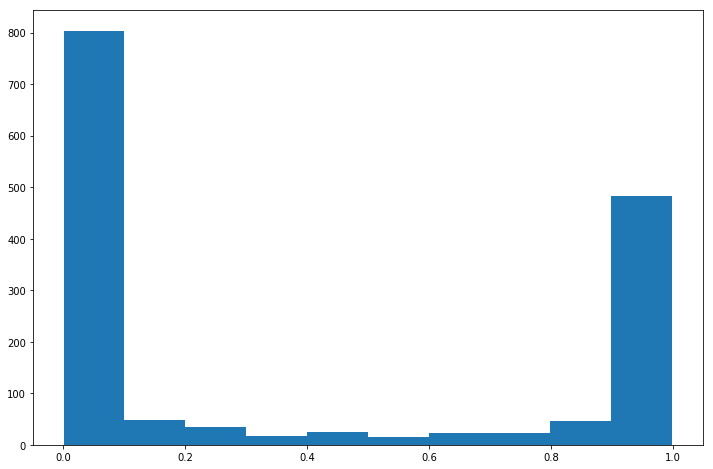

In [13]:
plt.hist(preds)
plt.show()

In [14]:
metrics.accuracy_score(y_test, preds>0.5)

0.9539170506912442

## Let's think about tuning: What happens when number of trees is large?

In [15]:
#First, what happens to training error when the number of trees gets large?
preds = bst.predict(train_dm)
metrics.accuracy_score(y_train, preds>0.5)

0.982154445165477

In [16]:
bst = xgb.train(param, train_dm, 1000)
preds = bst.predict(train_dm)
print(metrics.accuracy_score(y_train, preds>0.5))

preds = bst.predict(test_dm)
print(metrics.accuracy_score(y_test, preds>0.5))


0.9993510707332901
0.9611586570111915


Notice that the training error is getting better and better, but not the test error

We can cross-validate across the number of trees.  The argument below sets the max number to cross-validate up to

In [17]:
cvres = xgb.cv(param, train_dm, 1000)

In [18]:
cvres.head()

,test-logloss-mean,test-logloss-std,train-logloss-mean,train-logloss-std
0,0.624390,0.000140,0.620296,0.000400
1,0.568525,0.000170,0.560716,0.000780
2,0.521504,0.000469,0.510234,0.000892
3,0.481984,0.000360,0.467625,0.001062
4,0.448257,0.000894,0.430018,0.001599


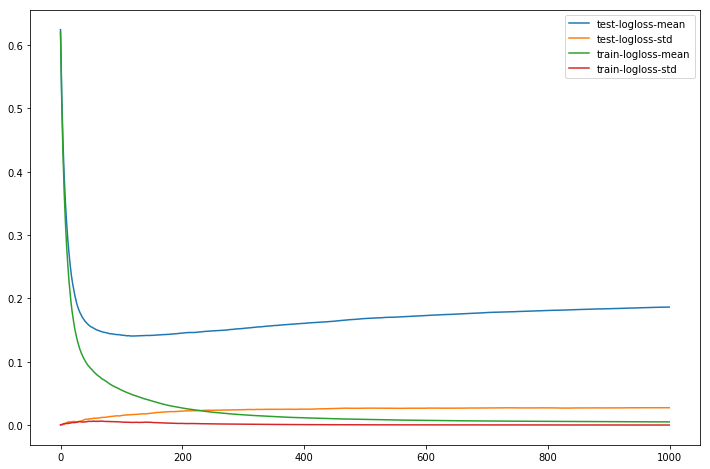

In [19]:
cvres.plot()
plt.show()

In [20]:
best_rounds = np.argmin(cvres['test-logloss-mean'])
best_rounds

/usr/local/lib/python3.5/dist-packages/numpy/core/fromnumeric.py:52: FutureWarning: 'argmin' is deprecated, use 'idxmin' instead. The behavior of 'argmin'
will be corrected to return the positional minimum in the future.
Use 'series.values.argmin' to get the position of the minimum now.
  return getattr(obj, method)(*args, **kwds)


118

In [21]:
bst = xgb.train(param, train_dm, best_rounds)
preds = bst.predict(train_dm)
print(metrics.accuracy_score(y_train, preds>0.5))

preds = bst.predict(test_dm)
print(metrics.accuracy_score(y_test, preds>0.5))


0.9841012329656067
0.956550362080316


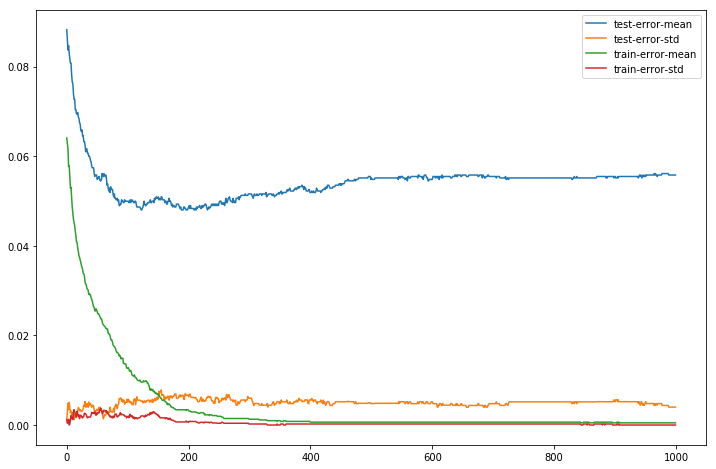

/usr/local/lib/python3.5/dist-packages/numpy/core/fromnumeric.py:52: FutureWarning: 'argmin' is deprecated, use 'idxmin' instead. The behavior of 'argmin'
will be corrected to return the positional minimum in the future.
Use 'series.values.argmin' to get the position of the minimum now.
  return getattr(obj, method)(*args, **kwds)


188

In [22]:
#We might be annoyed that the last was plotted in deviance.  We can change the error metric that we cross-validate
param2 = param.copy()
param2['eval_metric']='error'
cvres2 = xgb.cv(param2, train_dm, 1000)
cvres2.plot()
plt.show()
np.argmin(cvres2['test-error-mean'])

In [23]:
best_rounds2 = np.argmin(cvres2['test-error-mean'])

bst = xgb.train(param, train_dm, best_rounds2)
preds = bst.predict(train_dm)
print(metrics.accuracy_score(y_train, preds>0.5))

preds = bst.predict(test_dm)
print(metrics.accuracy_score(y_test, preds>0.5))


/usr/local/lib/python3.5/dist-packages/numpy/core/fromnumeric.py:52: FutureWarning: 'argmin' is deprecated, use 'idxmin' instead. The behavior of 'argmin'
will be corrected to return the positional minimum in the future.
Use 'series.values.argmin' to get the position of the minimum now.
  return getattr(obj, method)(*args, **kwds)


0.9918883841661259
0.9512837393021725


## Let's think about tuning: other parameters

#Now you might search over other parameters.  The xgb.cv function doesn't do that.  However, there is an sklearn wrapper for xgboost, XGBClassifier, which lets you use GridSearchCV

In [24]:
from xgboost.sklearn import XGBClassifier

In [25]:
xgbc = XGBClassifier(
    max_depth=6,#How deep should each tree be?
    eta=0.1,#The learning rate: how big are our steps?
    silent=1,#Whether to print out messages as you fit. 1 makes it quiet
    objective='binary:logistic',#What is our loss function? For now, logistic. Would change for multiclas
    gamma=0,#Would make it harder to get splits in trees
    subsample=1,#How much to subsample for each tree. Smaller number (like 0.5) would subsample
    colsample_bytree=1, #like the random forest restriction on variables
    eval_metric='logloss',
    min_child_weight=1,
    seed=1,
    n_estimators = best_rounds
)
fitted = xgbc.fit(X_train, y_train)

In [26]:
metrics.accuracy_score(y_test, fitted.predict(X_test))

0.956550362080316

In [27]:
from sklearn.model_selection import GridSearchCV 

In [28]:
param_grid1 = {
    'max_depth': range(2,9,3),
    'min_child_weight': [1,3,5]
}

In [29]:
grid_search = GridSearchCV(estimator=xgbc, param_grid = param_grid1, scoring='roc_auc', cv=5).fit(X_train, y_train)

In [30]:
grid_search.cv_results_

/usr/local/lib/python3.5/dist-packages/sklearn/utils/deprecation.py:125: FutureWarning: You are accessing a training score ('mean_train_score'), which will not be available by default any more in 0.21. If you need training scores, please set return_train_score=True
  warnings.warn(*warn_args, **warn_kwargs)
/usr/local/lib/python3.5/dist-packages/sklearn/utils/deprecation.py:125: FutureWarning: You are accessing a training score ('split0_train_score'), which will not be available by default any more in 0.21. If you need training scores, please set return_train_score=True
  warnings.warn(*warn_args, **warn_kwargs)
/usr/local/lib/python3.5/dist-packages/sklearn/utils/deprecation.py:125: FutureWarning: You are accessing a training score ('split1_train_score'), which will not be available by default any more in 0.21. If you need training scores, please set return_train_score=True
  warnings.warn(*warn_args, **warn_kwargs)
/usr/local/lib/python3.5/dist-packages/sklearn/utils/deprecation.py:1

{'mean_fit_time': array([0.26077752, 0.26048636, 0.2561748 , 0.59529471, 0.57596636,
        0.5662663 , 0.95674577, 1.29212856, 0.87860303]),
 'mean_score_time': array([0.00312734, 0.00307145, 0.00313616, 0.00410914, 0.00421739,
        0.00459127, 0.00553899, 0.00715432, 0.00495   ]),
 'mean_test_score': array([0.98174784, 0.98134608, 0.98126963, 0.98491538, 0.98331023,
        0.98283444, 0.98458562, 0.98413568, 0.98266697]),
 'mean_train_score': array([0.98921562, 0.98871786, 0.9885155 , 0.9982629 , 0.99755834,
        0.99655808, 0.9998334 , 0.99940847, 0.99871931]),
 'param_max_depth': masked_array(data=[2, 2, 2, 5, 5, 5, 8, 8, 8],
              mask=[False, False, False, False, False, False, False, False,
                    False],
        fill_value='?',
             dtype=object),
 'param_min_child_weight': masked_array(data=[1, 3, 5, 1, 3, 5, 1, 3, 5],
              mask=[False, False, False, False, False, False, False, False,
                    False],
        fill_value='

The best classifier is and the best parameters are both stored in the returned object by default, so you can directly call predict

In [31]:
metrics.accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))

0.9578670177748518

In [32]:
grid_search.best_estimator_.get_xgb_params()

{'base_score': 0.5,
 'booster': 'gbtree',
 'colsample_bylevel': 1,
 'colsample_bytree': 1,
 'eta': 0.1,
 'eval_metric': 'logloss',
 'gamma': 0,
 'learning_rate': 0.1,
 'max_delta_step': 0,
 'max_depth': 5,
 'min_child_weight': 1,
 'missing': None,
 'n_estimators': 118,
 'nthread': 1,
 'objective': 'binary:logistic',
 'reg_alpha': 0,
 'reg_lambda': 1,
 'scale_pos_weight': 1,
 'seed': 1,
 'silent': 1,
 'subsample': 1}

In [33]:
#We can retune the number of trees
param3 = grid_search.best_estimator_.get_xgb_params()
cvres = xgb.cv(param3, train_dm, 1000)
best_rounds3 = np.argmin(cvres['test-logloss-mean'])


/usr/local/lib/python3.5/dist-packages/numpy/core/fromnumeric.py:52: FutureWarning: 'argmin' is deprecated, use 'idxmin' instead. The behavior of 'argmin'
will be corrected to return the positional minimum in the future.
Use 'series.values.argmin' to get the position of the minimum now.
  return getattr(obj, method)(*args, **kwds)


In [34]:
bst = xgb.train(param3, train_dm, best_rounds3)
preds = bst.predict(train_dm)
print(metrics.accuracy_score(y_train, preds>0.5))

preds = bst.predict(test_dm)
print(metrics.accuracy_score(y_test, preds>0.5))


0.982154445165477
0.9572086899275839


In [40]:
#We would get the same performance fitting with the sklearn style wrapper
#Can use ** to unwrap the param dictionary into the sklearn format
param3['n_estimators'] = best_rounds3
xgbc = XGBClassifier(**param3)
fitted = xgbc.fit(X_train, y_train)
metrics.accuracy_score(y_test, fitted.predict(X_test))

0.9572086899275839

We can then continue this pattern with other parameters, especially subsample sizes, eta, gamma, and maybe regularization

## Diagnostics for boosting

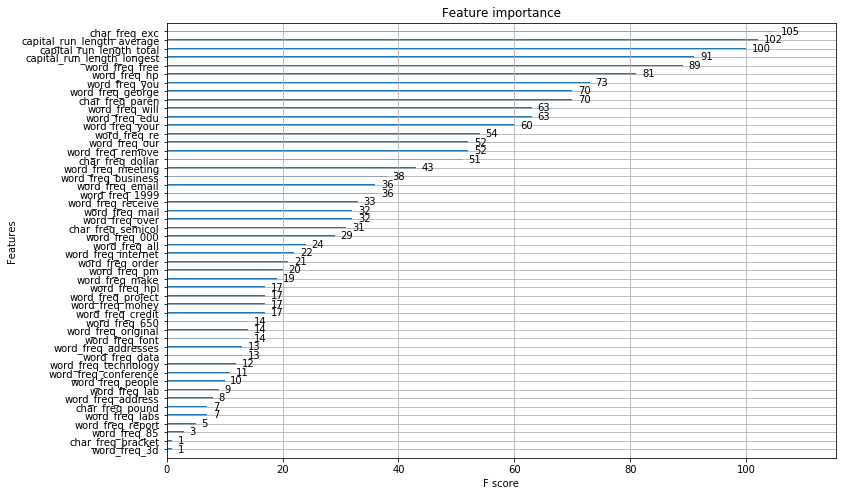

In [41]:
xgb.plot_importance(fitted)
plt.show()

In [42]:
from pdpbox import pdp

In [45]:
pdpobj = pdp.pdp_isolate(fitted, X_test, feature='char_freq_exc', model_features=X_test.columns)

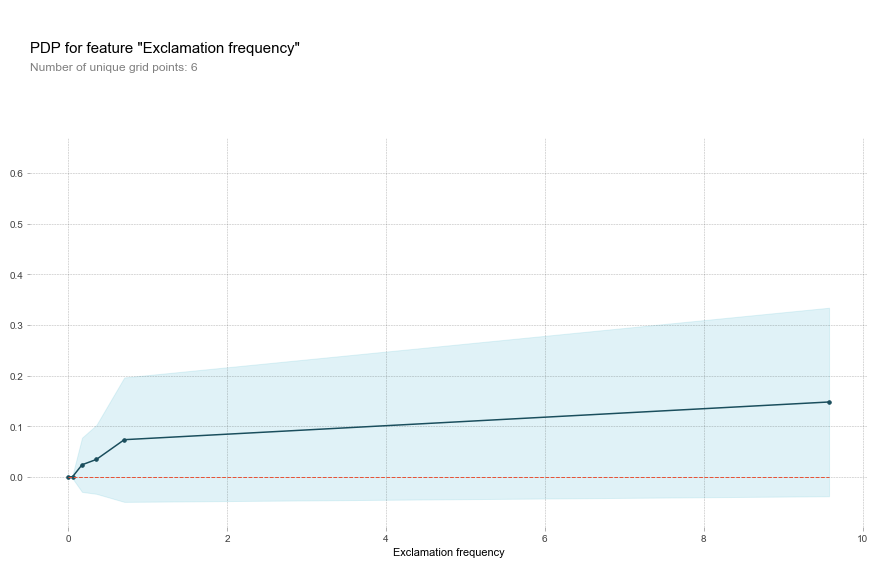

In [46]:
pdp.pdp_plot(pdpobj, 'Exclamation frequency')
plt.show()

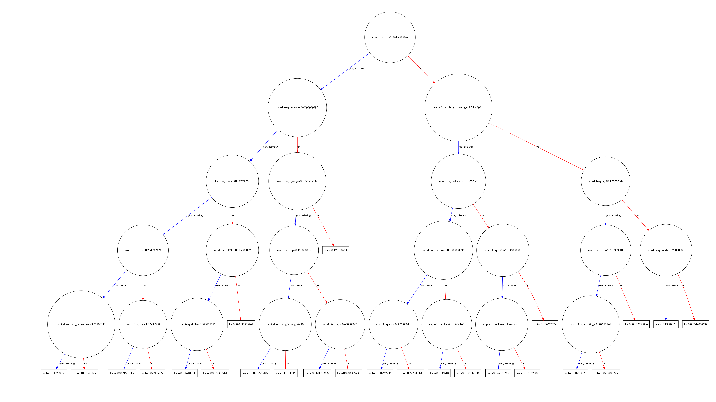

In [47]:
#Just for fun, though I can't imagine a reason you really want it, you can plot
#single trees...
xgb.plot_tree(fitted, num_trees=3)
plt.show()